# Notebook 4B: First Supervised Model with CalEnviroScreen: Linear Regression

*Authored by Dr. Noelle Anderson in 2026*

## Introduction

In Notebook 4A, you prepared the **CalEnviroScreen** dataset for supervised learning. You identified a target, practiced thinking about column roles, removed rows where the outcome `Asthma` was missing, and learned how `X`, `y`, training data, and test data fit into a supervised workflow.

In this notebook, you will build your first supervised learning model using the same tract-level public health outcome:

- **`Asthma`**: the age-adjusted rate of emergency department visits for asthma

Because `Asthma` is a **number**, this is a **regression** problem. Regression is a kind of supervised learning where the goal is to predict a numerical outcome.

For this first fitted regression model, we will choose a focused set of environmental burden variables as the model features. Other columns remain part of the dataset, but they are not part of today’s model inputs.

`Asthma` is a useful first regression target here because it is:
- a meaningful public health outcome
- measured numerically
- connected to environmental burdens in ways that make sense to study at the census-tract level

By the end of this notebook, you should be able to:

- explain what **regression** and **linear regression** mean in simple terms
- explain what **interpretability** means in machine learning
- prepare a supervised regression dataframe
- choose a focused first feature set for a model
- create `X` and `y`
- split the rows into training and test sets
- explain why preprocessing must happen **after** the split
- check whether imputation is needed
- scale features with `StandardScaler`
- fit a `LinearRegression` model
- use `predict()` to make numerical predictions
- evaluate the model with **RMSE** and **R²**
- inspect and interpret the model's largest coefficients carefully

## Notebook roadmap


In this notebook, we will follow the first full supervised regression workflow in three parts.

**Part 1: Prepare the data for regression**

1. Review regression, linear regression, and interpretability
2. Reload the CalEnviroScreen data and prepare a regression dataframe
3. Use domain knowledge to choose a focused first feature set
4. Create `X` and `y`
5. Split the rows into training and test sets
6. Check whether imputation is needed
7. Scale the features

**Part 2: Fit the linear regression model**

8. Fit a linear regression model
9. Make predictions

**Part 3: Evaluate and interpret the model**

10. Inspect predictions visually
11. Evaluate the model with RMSE and R²
12. Interpret the largest coefficients carefully

# Part 1: Prepare the data for regression


## Quick bridge from Notebook 4A

In Notebook 4A, you learned an important supervised learning habit:

- first decide what the target is
- then decide which columns make sense as possible features
- then make sure the outcome is usable
- then split the rows
- then do value-based preprocessing like imputation and scaling

You also practiced thinking about columns that need special care, like location columns, other health outcome columns, and columns that are too closely tied to the target.

In this notebook, we will take the next step. We will choose a smaller set of environmental burden variables for the first fitted model. This is a modeling choice, not a claim that only environmental variables matter for asthma burden.

That preprocessing order still matters a lot here.

In Notebook 1B, you scaled the whole dataset before PCA. That made sense for that **unsupervised** workflow. In supervised learning, though, preprocessing can create **leakage** if we let the test rows influence what we learn during preprocessing.

So in this notebook, we will keep reinforcing a general machine learning habit:

- choose the target and features
- split the rows
- fit preprocessing steps on the training data
- apply those learned transformations to both training and test data

## What is regression, and why start with linear regression?

A **regression** problem is a supervised learning problem where the goal is to predict a **number**.

Some examples:
- predict blood pressure from clinical measurements
- predict enzyme activity from experimental variables
- predict pollutant concentration from site conditions
- predict a tract-level health outcome such as `Asthma`

A **linear regression** model is one of the simplest regression models. It learns a set of weights, one for each feature, and combines them to make a numerical prediction.

One way to think about it is as a weighted scorecard:

- each feature can push the prediction up or down
- some features matter more than others
- the model learns those weights from the training data

People often start with linear regression because it is:
- simple
- fast
- a useful baseline
- often easier to interpret than more complex models

### What does interpretability mean?

In machine learning, **interpretability** means how easily we can understand what a model is doing and how it is using the input features to make predictions.

That matters because a model is often more useful if we can do more than just get a prediction. We also want to ask questions like:

- Which features is the model using most strongly?
- Is a feature associated with pushing the prediction up or down?
- Do the model's patterns make sense in context?

Linear models have an advantage here: they give us one **coefficient** per feature, so we can inspect the model's learned weights directly. That does not mean the model is automatically correct or causal, but it does make the model easier to examine.

## Step 0: Import the packages we need

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression # New today!
from sklearn.metrics import root_mean_squared_error, r2_score # New today!

Today you will see three very important `sklearn` verbs again:

- `fit()` means **learn from data**
- `transform()` means **use what was learned to change data**
- `predict()` means **use a fitted model to make predictions**

You saw `fit()` and `transform()` earlier with `StandardScaler` and PCA. In this notebook, you will review those ideas and also meet `predict()` for the first time.

## Step 1: Load the CalEnviroScreen data from Google Drive

In [ ]:
# Do not change this, it is loading in the file from a publicly shared link
file_id = "1X4-6X3VKhR2jRHppI3XuVV79nhHyg8Xb"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Use Census Tract as the dataframe index, just like you used patient_id as an index earlier
ces = pd.read_csv(url, index_col="Census Tract")

### <font color=0D9488>**Question 1:**</font> Print the shape of the dataset and the first 5 rows so you can confirm that the data loaded correctly.

In [ ]:
# Your solution here!

## Step 2: Prepare the regression dataframe

For this notebook, our target is `Asthma`. Before we can model it, we need to remove rows where `Asthma` is missing because supervised learning needs a known answer for each training example.

We are not dropping all unused columns from the dataframe here. Instead, we will keep the dataset intact after removing rows with missing `Asthma`, then choose the exact model inputs with `model_features` in the next step.

This keeps the workflow simple:

1. remove rows where the target is missing
2. choose the features for today’s model
3. create `X` and `y`

In [ ]:
# Remove rows where the target is missing
ces_sup_clean = ces.dropna(subset=["Asthma"]).copy()

### <font color=0D9488>**Question 2:**</font> Print the shape of `ces_sup_clean` and display the first 5 rows so you can confirm that the regression dataframe was built correctly.

In [ ]:
# Your solution here!

`ces_sup_clean` still contains many columns from the original dataset. That is okay because we will choose the exact columns we want the model to use in `model_features`.

This distinction matters: keeping a column in the dataframe is not the same thing as using it as a model feature.

## Step 3: Use problem framing to choose a focused first feature set

In machine learning, **problem framing** means deciding what question we want the model to answer and which inputs make sense for that question.

In Notebook 4A, we created a broad set of `possible_feature_cols`. In this notebook, we will make a narrower modeling choice by creating a smaller list called `model_features`. These are the columns the model will actually use as inputs today.

For this first regression notebook, our model question is: **How well can we predict tract-level asthma burden from environmental burden variables in CalEnviroScreen?**

This question focuses on environmental burden because environmental justice asks us to pay close attention to how pollution and environmental harm are distributed across communities. Variables like air pollution, diesel particulate matter, traffic, pesticide burden, drinking water burden, and cleanup-site burden are shaped by policy decisions, land use, segregation, disinvestment, labor patterns, and unequal political power.

Social and demographic variables also matter. Poverty, race, ethnicity, housing burden, linguistic isolation, and related variables may be strongly connected to asthma burden, but they require careful interpretation because they often reflect broader structural conditions rather than simple direct causes. For this first fitted model, using only environmental burden variables keeps the model question focused and makes the coefficient table easier to interpret. It gives us one entry point into a broader environmental justice problem, not the whole story.

In [ ]:
# Instructor-provided feature set for this first model
model_features = [
    "Ozone",
    "PM2.5",
    "Diesel PM",
    "Drinking Water",
    "Pesticides",
    "Traffic",
    "Cleanup Sites"
]

print("Features for this first regression model:")
print(model_features)

Features for this first regression model:
['Ozone', 'PM2.5', 'Diesel PM', 'Drinking Water', 'Pesticides', 'Traffic', 'Cleanup Sites']


## Step 4: Create `X` and `y`

Now we are ready to separate the data by **column role**.

- `y` will be the outcome column we want to predict: `Asthma`
- `X` will contain the selected feature columns

`X` and `y` are standard names in machine learning. `X` means the input columns we use for prediction, also called **features** or sometimes **independent variables**. `y` means the outcome column we want to predict, also called the **dependent variable**.

### <font color=0D9488>**Question 3:**</font> Create `X` and `y` from `ces_sup_clean`. Use `Asthma` as `y`, and use only the columns in `model_features` for `X`. Then print the shapes of `X` and `y`, and display the first 5 rows of `X`.

In [ ]:
# Your solution here!

## Step 5: Split the rows into training and test sets

Up to this point, we have separated the data by **column role**.

Now we are going to do a different kind of split. This time, we will split the **rows** into two groups:

- the **training set**, which the model will learn from later
- the **test set**, which we will hold aside until after training so we can check how well the model performs on rows it has not seen before

Usually, the training set is larger than the test set. A common starting choice is to use about **80%** of the rows for training and **20%** for testing.

This split is usually done **randomly** so that both groups are mixed samples from the same dataset. In `sklearn`, we often use a fixed `random_state` so that we get the same split each time we run the notebook. That makes the work reproducible.

Notice the difference between the two kinds of splitting you have now seen:

- when we created `X` and `y`, we split the data by **column role**
- now we will split the rows by **use**

### Predict before running

Before you run the next code cell, pause and think:

- If `X` and `y` start with the same number of rows, what should be true about `X_train` and `y_train`?
- Why do we split `X` and `y` together instead of splitting them separately?
- Why do we usually keep more rows in the training set than in the test set?

### <font color=0D9488>**Question 4:**</font> Use `train_test_split()` to split `X` and `y` into training and test sets using 20% of the data as test data and using `random_state=42`. Then print the shapes of `X_train`, `X_test`, `y_train`, and `y_test`.

*Hint: feel free to reference notebook 4A as needed*

In [ ]:
# Your solution here!

## A quick reminder: supervised preprocessing is different from unsupervised preprocessing

In Notebook 1B, you used `StandardScaler` on the full dataset before PCA. That made sense there because PCA was part of an **unsupervised** workflow. We were not trying to protect a separate test set for later evaluation.

In supervised learning, the situation is different. Once we split the rows into **training** and **test** sets, we want the test set to stay separate from anything the model learns during training. That includes preprocessing steps like:

- **imputation**, which learns values such as medians
- **scaling**, which learns values such as means and standard deviations

So in supervised learning, we usually:
- split the rows first
- fit preprocessing steps on the training data only
- apply those learned transformations to both the training and test data

This helps us avoid **leakage** and makes our later evaluation more trustworthy.

## Step 6: Check whether missing value imputation is needed

In supervised learning, **imputation** means filling in missing feature values using a chosen rule, like the median.

In supervised learning, we usually do imputation **after** the train/test split so that the test rows do not influence what we learn during preprocessing.

For example, you can imagine we want to fill in missing values with the column median, but doing it on the full dataset *then* splitting test and training data would mean the test data would have information about the training data since the imputed values came from the full distribution. So in supervised learning we usually need to impute and preprocess the test and train data separately.

Some possible feature columns in the full supervised-learning dataframe we saw in 4A do have missing values. However, the environmental burden variables we selected for this first model do not have missing values in the rows we are using. That means we do not need to impute missing feature values in this notebook.

Even though we are skipping imputation in this specific model, the workflow rule still matters:

- if missing feature values were present, we would split first
- then fit the imputation rule on `X_train`
- then apply it to both `X_train` and `X_test`

We will demonstrate this next week.

### <font color=0D9488>**Question 5:**</font> Double-check that each selected feature has 0 missing values in `X_train` and `X_test`.

In [ ]:
# Your solution here!

In this first fitted model, our selected training and test features do not have missing values, so we do not need to do any imputation here.

That means we can move directly to scaling! If missing feature values had been present, we would have handled them **after** the train/test split here so that the test rows would not influence what we learn during preprocessing.

If you want to learn more about how imputation works in supervised learning, here is a [tutorial](https://www.blog.trainindata.com/imputing-missing-data-with-scikit-learns-simple-imputer/) you can explore outside the live sessions.

## Step 7: Scale the features

Before we fit the linear regression model, we need to scale the features.

You saw scaling before in Notebook 1B, when you used `StandardScaler` before PCA. In that unsupervised workflow, we scaled the **whole dataset** before running PCA because there was no target variable, no train/test split, and no held-out test set.

The tool is the same here, but the workflow is different because this is now **supervised learning**.

In supervised learning, we split the rows into training and test sets before fitting preprocessing steps like scaling. The test set is supposed to act like new, unseen data. If we fit the scaler on the full dataset before splitting, then the test rows would help determine the feature means and standard deviations. That would leak information from the test set into the modeling process.

So we use this order:

1. split into training and test sets
2. fit the scaler on `X_train`
3. transform `X_train`
4. transform `X_test` using the scaler learned from `X_train`

We scale here because linear regression uses the feature values directly, and our environmental variables are measured on different scales. Scaling helps make the features more comparable, and it makes the coefficients easier to compare later.

The important rule is that the scaler learns the feature means and standard deviations from the training data only, but we apply that same learned scaling to both the training data and the test data.

### <font color=0D9488>**Question 6:**</font> Create a `StandardScaler` object and save it as the variable `scaler`.

*Reference notebook 1B as needed*

In [ ]:
# Your solution here!

Now we will scale the features using the supervised-learning order.

`fit_transform(X_train)` does two things at once:

1. `fit`: learn the mean and standard deviation from the training data
2. `transform`: use those learned values to scale the training data

For the test data, we only use `transform(X_test)`. We do **not** fit the scaler on the test data, because the test set is supposed to act like new, unseen data.

In [ ]:
# Fit on the training data only, then transform the training data in the same step
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using ONLY the scaling values learned from X_train
# Notice we do NOT fit the scaler on/learn from the test data!
# transform alone vs fit_transform
X_test_scaled = scaler.transform(X_test)

# Part 2: Fit the linear regression model


## Step 8: Fit a linear regression model

Now we are ready to train our first regression model.

In `sklearn`, this means:
- create the model
- use `fit()` on the training data
- let the model learn weights, also called **coefficients**

The code below is provided because this is your first time fitting a supervised regression model. Focus on what `fit()` means here.

In [ ]:
# Instructor-provided model fitting
linr_model = LinearRegression()
linr_model.fit(X_train_scaled, y_train)

LinearRegression()

For the model itself, `fit()` means: learn the relationship between the feature columns and the outcome using the training data.

## Step 9: Make predictions with `predict()`

Now we will use the fitted model to make predictions on the **test** features.

This is the first time you are using `predict()` in this course.

- `fit()` learns from data
- `predict()` uses what was learned to generate predicted outcome values

The code below is provided so you can focus on understanding what prediction means before you write more of this yourself in later notebooks.

In [ ]:
# Notice predict!
y_pred = linr_model.predict(X_test_scaled)

comparison_df = pd.DataFrame({
    "Actual Asthma": y_test.iloc[:10].values,
    "Predicted Asthma": y_pred[:10].round(2)
})

display(comparison_df)

,Actual Asthma,Predicted Asthma
0,36.67,38.08
1,38.97,37.84
2,47.30,43.46
3,51.29,38.72
4,63.27,40.18
5,30.45,38.56
6,73.95,41.70
7,20.62,36.44
8,22.23,30.71
9,27.37,39.84


The predicted values will usually not match the true values exactly. The difference between an actual value and a predicted value is called a **residual** or **prediction error**.

For one row:

- residual = actual value - predicted value

If a prediction is very close to the true value, the residual is small. If a prediction is far off, the residual is large.

Later in this notebook, we will learn a metric called RMSE that will summarize the typical size of those residuals across the test set.

# Part 3: Evaluate and interpret the model


### A quick visual check: actual vs predicted values

A simple scatterplot can help us see how close the predictions are to the true values.

- each point represents one census tract in the test set
- the x-axis shows the actual `Asthma` value
- the y-axis shows the predicted `Asthma` value

If predictions were perfect, all the points would fall exactly on the diagonal line.

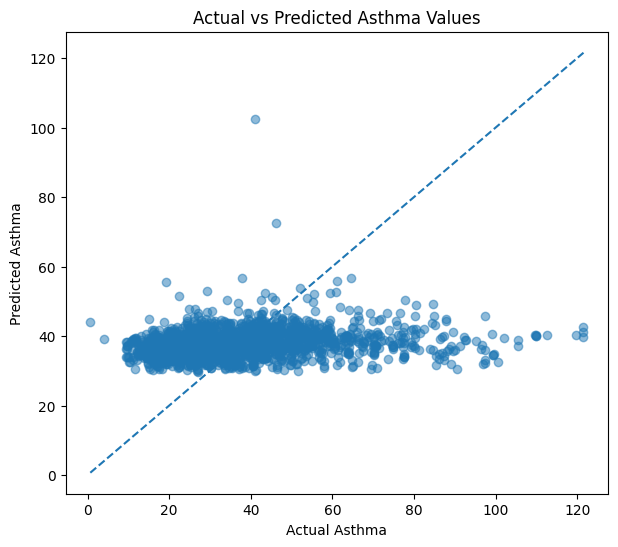

In [ ]:
# Instructor-provided plot
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")

plt.xlabel("Actual Asthma")
plt.ylabel("Predicted Asthma")
plt.title("Actual vs Predicted Asthma Values")
plt.show()

Points closer to the dashed diagonal line have smaller residuals. Points farther from that line have larger residuals.

This plot suggests that the model is predicting many tracts in a fairly narrow middle range rather than matching the full spread of the true asthma values. That means the model is not doing a strong job capturing the patterns in the lowest asthma-burden tracts or the highest asthma-burden tracts.

So even before we calculate formal measures of how well our model is performing, this visual check suggests that our initial linear model is a weak baseline model rather than a highly accurate predictor.

## Step 10: Model Metrics: Evaluating the model with RMSE and R²

How can we tell whether a model is doing a good job?

In clustering, you used tools like the elbow plot of inertia and the silhouette score to help evaluate unsupervised results. In supervised learning, we use different evaluation metrics, because now we are comparing model predictions to known outcome values.

A **metric** is a summary measure we use to judge how well a model is performing.

Earlier, you saw **residuals**, which in regression are the differences between the **true values** and the **model's predictions**. Residuals give us one way to think about model error: smaller residuals usually mean the predictions are closer to the real values.

Because supervised learning can involve different kinds of outcomes, it also uses different kinds of metrics. In **regression**, where we predict numbers, we use metrics designed for numerical prediction error. In **classification**, where we predict categories, we use different metrics. Here, you will learn two key metrics for regression.

Once we have many test rows, looking at residuals one by one is not enough. We need summary measures that help us judge model performance more systematically.

---

### RMSE (Root Mean Squared Error)

RMSE is a common metric for measuring a regression model's prediction error. Think of it as a magnified measure of the typical distance between the model's predictions and the actual values. **Lower RMSE is better.**

RMSE is measured in the same units as our target variable, `Asthma`, so it is easier to understand than some other metrics. For example, an RMSE of 10 suggests that the model's predictions are typically off by about 10 asthma-rate units. Some predictions will be closer than that, and others will be farther away, but RMSE gives us one summarized score for the model's prediction error.

Technically, RMSE comes from residuals, which are the individual gaps between a true value and a prediction. By squaring these gaps before averaging them, RMSE gives more weight to larger errors. That means big misses affect the final score more strongly.

---

### R² (Coefficient of Determination)

$R^2$ measures how much of the **variation** in `Asthma` rates the model explains. While RMSE tells us the size of our prediction errors, $R^2$ tells us how much of the overall pattern in the target variable the model is capturing.

**Why do we care about variation?**

In any dataset, the values differ from row to row. That spread is called **variation**. If a model does not capture much of that variation, it may be doing something close to predicting the average value for many rows.

We care about captured variation because it tells us whether the model's predictions are tracking patterns in the target variable. However, even when a model captures variation, that does **not** prove that the features are causes. A predictive pattern is not the same as a causal explanation.

**Interpreting $R^2$:**

- **near 1.0:** The model explains most of the variation in the data.
- **near 0.0:** The model explains very little of the variation and may be doing little more than predicting near the average.
- **negative values:** The model is performing worse than a simple baseline that predicts the average.

Let's now calculate the test-set RMSE and R² using `y_test` and `y_pred`.

In [ ]:
# RMSE
rmse = root_mean_squared_error(y_test, y_pred)

# R^2
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 3))
print("R^2:", round(r2, 3))

RMSE: 18.11
R^2: 0.039


### <font color=0D9488>**Question 7:**</font> In your own words, what does the RMSE tell you about this model, and what does the R² tell you? Keep your answer practical rather than formula-based.

**Your solution here!**

## Step 11: Interpret the model coefficients

One reason people often start with **linear models** is that they are more **interpretable** than many more complex models.

In machine learning, **interpretability** means how easily we can understand what a model is doing and how it is using the input features to make predictions.

A linear regression model learns one **coefficient** for each feature. A coefficient is the weight the model gives that feature when making predictions.

Because we scaled the features before fitting the model, the coefficients are easier to compare across features. In general:

- a **positive** coefficient means the model tends to predict **higher** `Asthma` values when that feature is higher
- a **negative** coefficient means the model tends to predict **lower** `Asthma` values when that feature is higher
- a **larger absolute value** means the model is using that feature more strongly in its predictions, relative to the other scaled features in this fitted model

This is one interpretability advantage of linear regression: instead of being a black box, it gives us weights we can inspect and discuss.

That matters here because interpretability can help us ask not just which environmental burdens the model is using strongly, but also how those burdens may reflect unequal protection, unequal exposure, and unequal political power across communities.

In a model with several features at once, a coefficient does not show a simple one-variable relationship by itself. It shows how the fitted model is using that feature alongside the others in the model.

Because this model's overall predictive performance is weak, we should be especially cautious about reading too much into any one coefficient.

At the same time, these are still **model-based associations**, not proof of causation. A coefficient helps us understand how the model is using a feature, but it does not prove that changing that feature would directly change asthma burden.

---

The fitted model stores one coefficient for each feature. The code below pulls those coefficients out of the model with `model.coef_` and places them into a table so we can inspect them more easily.

We will also compute the **absolute value** of each coefficient. That helps us sort the table by how strongly the model is using each feature, regardless of whether the direction is positive or negative.

In [ ]:
# Instructor-provided coefficient table
coef_df = pd.DataFrame({
    "Feature": X_train.columns, # just getting the feature names here, can use the original dataset
    "Coefficient": linr_model.coef_ # Notice how we extract the model coefficients with .coef_
})

# Get absolute values and make a sorted table
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)

display(coef_df)

,Feature,Coefficient,AbsCoefficient
0,Ozone,2.549908,2.549908
6,Cleanup Sites,2.309441,2.309441
2,Diesel PM,1.290042,1.290042
5,Traffic,-0.948695,0.948695
3,Drinking Water,0.888648,0.888648
4,Pesticides,-0.085136,0.085136
1,PM2.5,0.031216,0.031216


### <font color=0D9488>**Optional— Question 8:**</font> Choose the top 2 positive coefficients and the top 2 negative coefficients. For each one, describe what the sign means in this fitted model and what the relative size suggests about how strongly the model is using that feature. Be careful not to describe the coefficients as causal effects.

**Your solution here!**

### Why can a coefficient be negative even when the feature seems harmful?

Negative coefficients can feel surprising, especially for variables like `Traffic` or `Pesticides`, where we might expect higher exposure to be connected to worse health outcomes.

In this model, a negative coefficient does **not** mean that traffic or pesticides protect people from asthma. It only means that, **within this particular linear model and this particular set of features**, tracts with higher values for that feature tend to receive lower predicted asthma values after the model has also accounted for the other features.

There are a few reasons this can happen:

- The model is weak overall, so individual coefficients should not be overinterpreted.

- Several environmental burden variables may overlap with each other, so the model is trying to separate patterns that are not actually cleanly separate in the real world. For example, tracts with high traffic burden may also tend to have higher diesel particulate matter or PM2.5 values. When these related features are included in the same model, the `Traffic` coefficient is not just comparing high-traffic tracts to low-traffic tracts overall. It is estimating the pattern associated with `Traffic` after the model has also used the other pollution variables. That can make the coefficient harder to interpret by itself.

- A feature may be acting as a proxy for other geographic, social, or structural patterns that are not included in this model.

- Linear regression is limited because it assumes each feature has a straight-line relationship with the target, which may be too simple for a complex public-health outcome like asthma burden.

The main takeaway is: **a coefficient sign is part of the model's prediction rule, not proof of a real-world cause.** Negative coefficients are a useful reminder that prediction and explanation are not the same thing.

## A note on structural inequality and careful interpretation

This first fitted model used only environmental burden variables as features to keep the first regression model narrower and easier to interpret.

That does **not** mean asthma burden is only environmental. Environmental exposures are patterned by power, policy, and history. Racism, segregation, disinvestment, labor conditions, housing policy, and unequal access to care all shape who is exposed, who is protected, and whose health burdens become more severe.

The `Cleanup Sites` variable is a good example. In CalEnviroScreen, cleanup sites are places where chemicals in buildings, soil, or water may move into nearby communities, and cleanup can take years or decades. Research on hazardous waste and Superfund sites has found that contaminated sites are often concentrated near communities of color and low-income communities, including Black, Latino, Asian, and Native American communities ([Toxic Wastes and Race](https://new.uccfiles.com/pdf/ToxicWastes%26Race.pdf), [Nature Communications](https://www.nature.com/articles/s41467-025-63607-8), [NIEHS](https://www.niehs.nih.gov/news/factor/2023/9/science-highlights/mining-tribal-lands)). These patterns reflect land use, regulation, political power, and whose neighborhoods are treated as acceptable places for environmental harm.

So even though this first model did not include demographic or broader structural variables in the fit, those realities are still part of the context we need to bring to interpretation. Race is not a biological explanation for asthma burden. Poverty is not a simple cause by itself. Variables like these often stand in for larger systems of environmental harm, discrimination, underinvestment, and unequal access to good care.

This model is also working with tract-level public health data, not individual patient data. That means the predictions and coefficients describe patterns across communities, not one person's health.

Finally, linear regression is still a very simple model. It can help us see patterns, but it cannot tell the full historical or political story on its own.

# Congratulations, you have completed today's notebook!

## Key Takeaways:

- You prepared the CalEnviroScreen data for supervised regression by removing rows with missing `Asthma` values
- You used `Asthma` as a numerical outcome for a regression problem
- You chose a focused environmental burden feature set for this first fitted model
- You created `X` from the selected `model_features` and `y` from `Asthma`
- You split the rows into training and test sets
- You checked whether imputation was needed for the selected features
- You scaled the features using `StandardScaler`
- You fit a `LinearRegression` model
- You used `predict()` to generate numerical predictions
- You connected prediction errors to residuals and RMSE
- You evaluated the model using RMSE and R²
- You inspected and interpreted the model's coefficients carefully
- You practiced separating prediction from causal explanation

## Where This Fits in the ML Workflow

This notebook completed the first full supervised regression workflow:

1. choose a target
2. choose features for the model
3. create `X` and `y`
4. split into training and test sets
5. preprocess after the split
6. fit a model
7. make predictions
8. evaluate performance
9. interpret results carefully

In the next notebook, we will continue building supervised learning skills and compare this workflow with a different kind of supervised problem: classification. Instead of predicting a number directly, classification models predict categories.

In the next notebook, we will continue building supervised learning skills and compare this workflow with a different kind of supervised problem.